In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# DATASET
data     = fetch_california_housing()
X_all    = data.data[:, 0].reshape(-1, 1)   
y_all    = data.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42
)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_s      = scaler_x.fit_transform(X_train_full)
X_test_s       = scaler_x.transform(X_test)
y_train_s      = scaler_y.fit_transform(y_train_full.reshape(-1,1)).flatten()
y_test_s       = scaler_y.transform(y_test.reshape(-1,1)).flatten()


# HELPER FUNCTIONS
def poly_features(X, degree):
    return np.hstack([X**d for d in range(0, degree + 1)])   # [1, x, x², ...]

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def gradient_descent_ridge(X, y, lr=0.01, iters=1000, lam=0.0):
    m, n  = X.shape
    theta = np.zeros(n)
    losses = []
    for _ in range(iters):
        pred  = X @ theta
        grad  = (2/m) * X.T @ (pred - y) + (2 * lam / m) * theta
        grad[0] -= (2 * lam / m) * theta[0]    # don't regularize bias
        theta = theta - lr * grad
        losses.append(mse(y, pred))
    return theta, losses

def gradient_descent_lasso(X, y, lr=0.005, iters=1000, lam=0.0):
    m, n  = X.shape
    theta = np.zeros(n)
    losses = []
    for _ in range(iters):
        pred  = X @ theta
        grad  = (2/m) * X.T @ (pred - y)
        # subgradient for L1
        l1_grad        = lam * np.sign(theta)
        l1_grad[0]     = 0                      # don't regularize bias
        theta = theta - lr * (grad + l1_grad)
        losses.append(mse(y, pred))
    return theta, losses




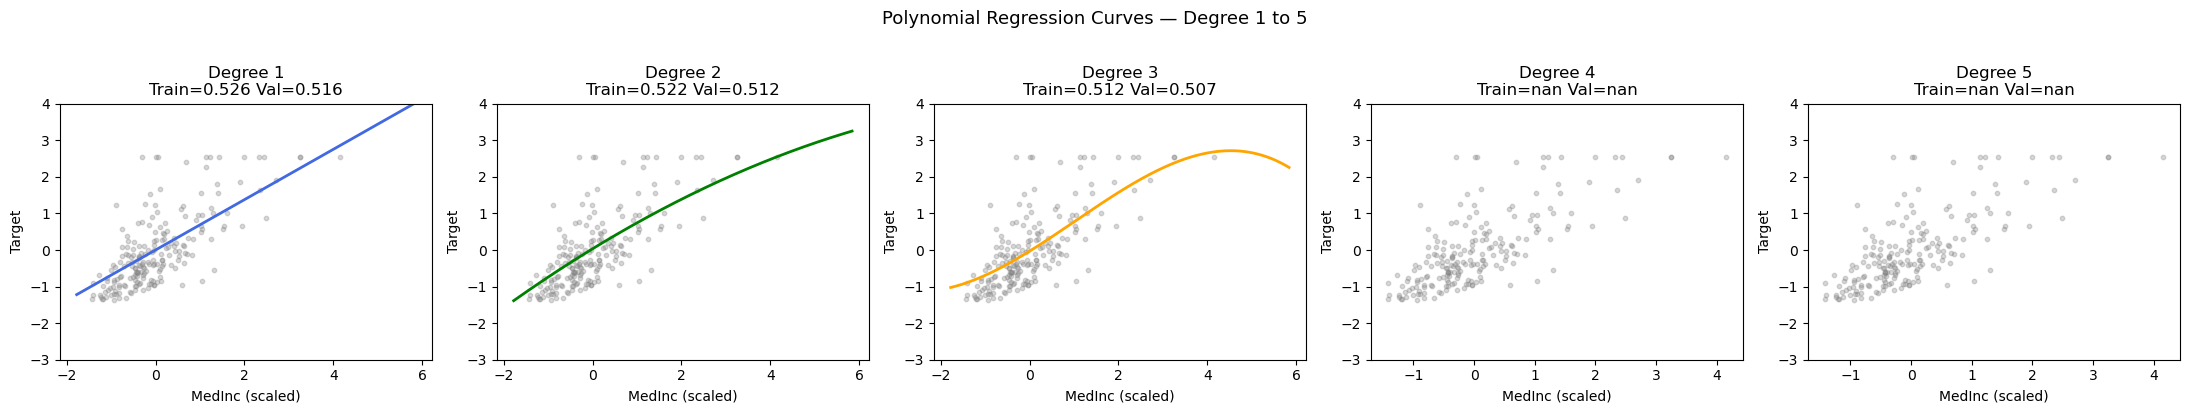

In [2]:
# PART 1A — Polynomial Regression for each degree
degrees    = [1, 2, 3, 4, 5]
colors_deg = ['royalblue', 'green', 'orange', 'crimson', 'purple']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

train_errors = []
val_errors   = []

for i, d in enumerate(degrees):
    X_tr_poly  = poly_features(X_train_s, d)
    X_val_poly = poly_features(X_test_s,  d)

    theta, _ = gradient_descent_ridge(X_tr_poly, y_train_s, lr=0.005, iters=2000, lam=0.0)

    tr_err  = mse(y_train_s, X_tr_poly  @ theta)
    val_err = mse(y_test_s,  X_val_poly @ theta)
    train_errors.append(tr_err)
    val_errors.append(val_err)

    # plot
    x_line     = np.linspace(X_train_s.min(), X_train_s.max(), 300).reshape(-1, 1)
    x_line_poly = poly_features(x_line, d)
    y_line     = x_line_poly @ theta

    axes[i].scatter(X_train_s[:200], y_train_s[:200], alpha=0.3, s=10, color='gray')
    axes[i].plot(x_line, y_line, color=colors_deg[i], linewidth=2)
    axes[i].set_title(f'Degree {d}\nTrain={tr_err:.3f} Val={val_err:.3f}')
    axes[i].set_xlabel('MedInc (scaled)')
    axes[i].set_ylabel('Target')
    axes[i].set_ylim(-3, 4)

plt.suptitle('Polynomial Regression Curves — Degree 1 to 5', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('poly_curves.png', dpi=150, bbox_inches='tight')
plt.show()




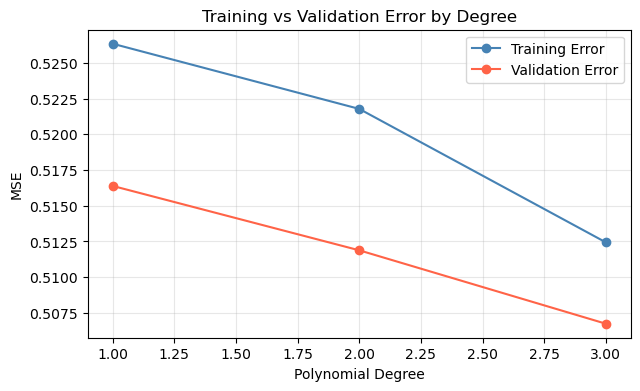


BIAS-VARIANCE OBSERVATIONS
Degree 1 → Underfitting: high train + val error (high bias)
Degree 2-3 → Good fit: both errors balanced
Degree 4-5 → Overfitting: low train error, high val error (high variance)


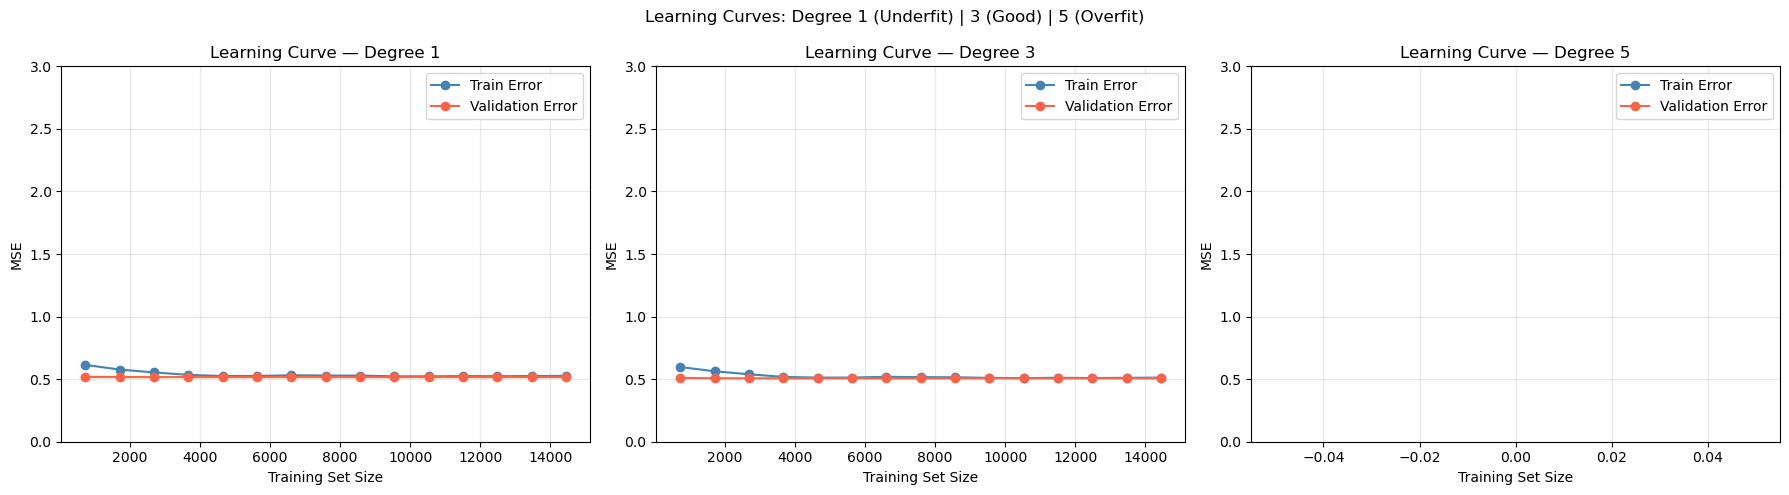

In [3]:
# PART 1B — Training and Validation Error vs Degree
plt.figure(figsize=(7, 4))
plt.plot(degrees, train_errors, 'o-', color='steelblue', label='Training Error')
plt.plot(degrees, val_errors,   'o-', color='tomato',    label='Validation Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('Training vs Validation Error by Degree')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('error_vs_degree.png', dpi=150)
plt.show()

# Observations printed to terminal
print("\n" + "="*60)
print("BIAS-VARIANCE OBSERVATIONS")
print("="*60)
print("Degree 1 → Underfitting: high train + val error (high bias)")
print("Degree 2-3 → Good fit: both errors balanced")
print("Degree 4-5 → Overfitting: low train error, high val error (high variance)")
print("="*60)


# PART 1C — Learning Curves (error vs training set size)
train_sizes = np.linspace(0.05, 1.0, 15)
fig, axes   = plt.subplots(1, 3, figsize=(18, 5))

for ax, d in zip(axes, [1, 3, 5]):
    tr_curve, val_curve, sizes = [], [], []

    for frac in train_sizes:
        n = max(int(frac * len(X_train_s)), d + 2)
        Xtr = poly_features(X_train_s[:n], d)
        Xva = poly_features(X_test_s,      d)
        ytr = y_train_s[:n]

        theta, _ = gradient_descent_ridge(Xtr, ytr, lr=0.005, iters=1000, lam=0.0)
        tr_curve.append(mse(ytr,      Xtr @ theta))
        val_curve.append(mse(y_test_s, Xva @ theta))
        sizes.append(n)

    ax.plot(sizes, tr_curve,  'o-', color='steelblue', label='Train Error',      linewidth=1.5)
    ax.plot(sizes, val_curve, 'o-', color='tomato',    label='Validation Error',  linewidth=1.5)
    ax.set_title(f'Learning Curve — Degree {d}')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 3)

plt.suptitle('Learning Curves: Degree 1 (Underfit) | 3 (Good) | 5 (Overfit)', fontsize=12)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()





RIDGE REGRESSION — Degree 4
Lambda       Train Loss       θ norm
0                   nan          nan
0.01                nan          nan
0.1                 nan          nan
1                   nan          nan
10                  nan          nan


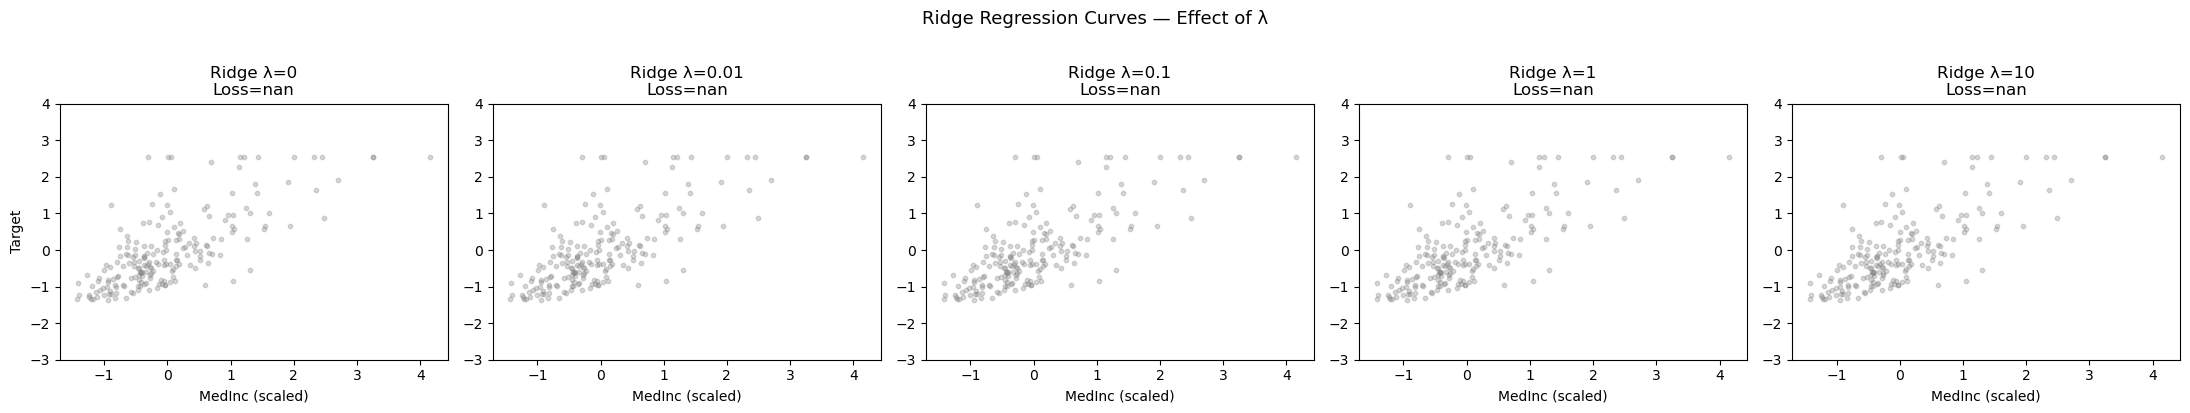

In [4]:
# PART 2A — Ridge Regression for different lambda values
lambdas      = [0, 0.01, 0.1, 1, 10]
colors_lam   = ['royalblue', 'green', 'orange', 'crimson', 'purple']
degree_ridge = 4       # use degree 4 so regularization effect is visible

X_tr_poly  = poly_features(X_train_s, degree_ridge)
X_val_poly = poly_features(X_test_s,  degree_ridge)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

print("\n" + "="*60)
print(f"RIDGE REGRESSION — Degree {degree_ridge}")
print(f"{'Lambda':<10} {'Train Loss':>12} {'θ norm':>12}")
print("="*60)

for i, lam in enumerate(lambdas):
    theta, losses = gradient_descent_ridge(X_tr_poly, y_train_s, lr=0.005, iters=2000, lam=lam)

    print(f"{lam:<10} {losses[-1]:>12.5f} {np.linalg.norm(theta[1:]):>12.5f}")

    x_line      = np.linspace(X_train_s.min(), X_train_s.max(), 300).reshape(-1, 1)
    x_line_poly = poly_features(x_line, degree_ridge)
    y_line      = x_line_poly @ theta

    axes[i].scatter(X_train_s[:200], y_train_s[:200], alpha=0.3, s=10, color='gray')
    axes[i].plot(x_line, y_line, color=colors_lam[i], linewidth=2)
    axes[i].set_title(f'Ridge λ={lam}\nLoss={losses[-1]:.3f}')
    axes[i].set_xlabel('MedInc (scaled)')
    axes[i].set_ylim(-3, 4)

axes[0].set_ylabel('Target')
plt.suptitle('Ridge Regression Curves — Effect of λ', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('ridge_curves.png', dpi=150, bbox_inches='tight')
plt.show()





LASSO REGRESSION — Degree 4
Lambda       Train Loss       θ norm  Zero params
0                   nan          nan            0
0.01                nan          nan            0
0.1                 nan          nan            0
1                   nan          nan            0
10                  nan          nan            0


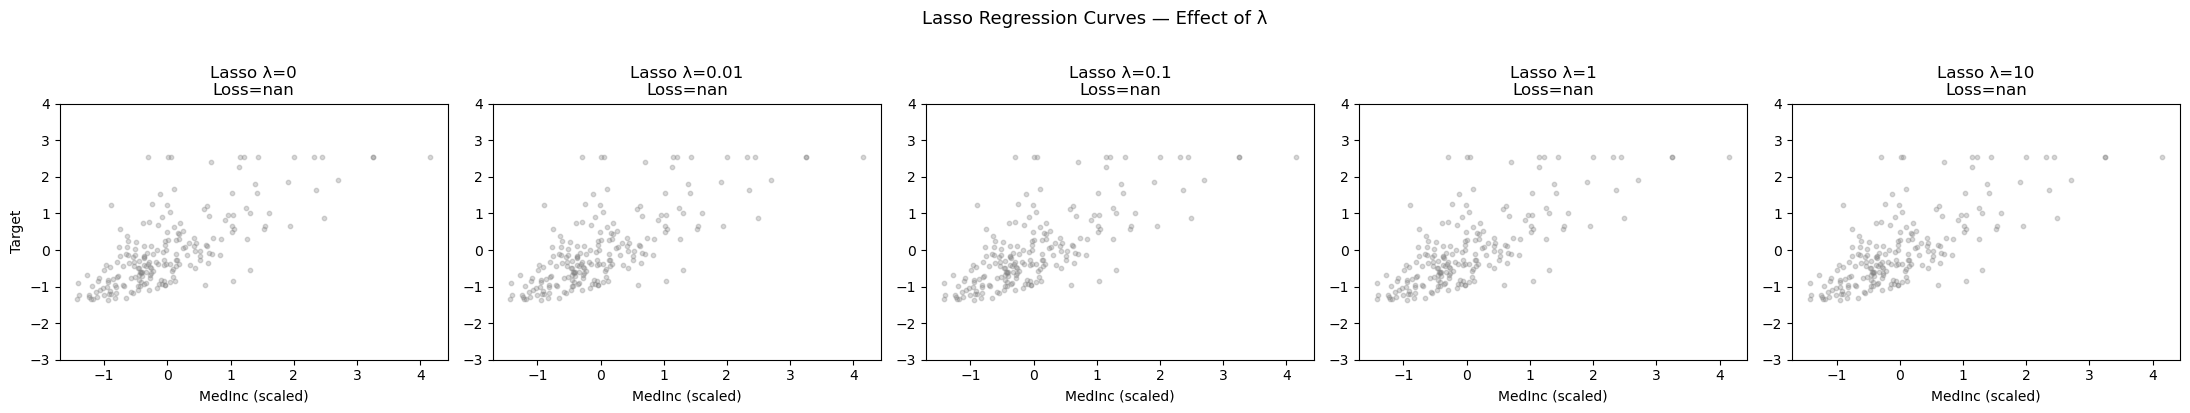

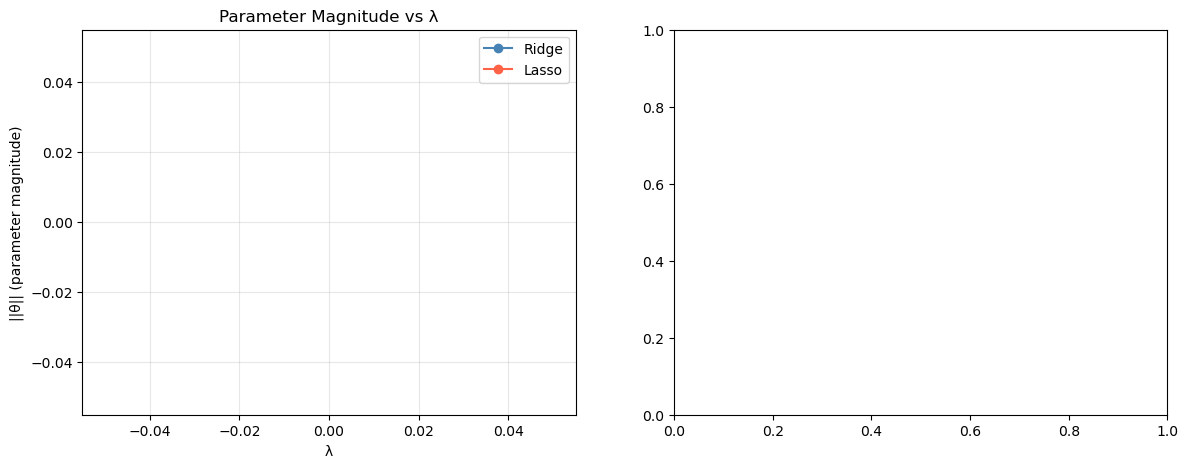

In [5]:
# PART 2B — Lasso Regression
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

print("\n" + "="*60)
print(f"LASSO REGRESSION — Degree {degree_ridge}")
print(f"{'Lambda':<10} {'Train Loss':>12} {'θ norm':>12} {'Zero params':>12}")
print("="*60)

lasso_thetas = []
for i, lam in enumerate(lambdas):
    theta, losses = gradient_descent_lasso(X_tr_poly, y_train_s, lr=0.005, iters=2000, lam=lam)
    lasso_thetas.append(theta)
    zero_params   = np.sum(np.abs(theta[1:]) < 1e-3)

    print(f"{lam:<10} {losses[-1]:>12.5f} {np.linalg.norm(theta[1:]):>12.5f} {zero_params:>12}")

    x_line      = np.linspace(X_train_s.min(), X_train_s.max(), 300).reshape(-1, 1)
    x_line_poly = poly_features(x_line, degree_ridge)
    y_line      = x_line_poly @ theta

    axes[i].scatter(X_train_s[:200], y_train_s[:200], alpha=0.3, s=10, color='gray')
    axes[i].plot(x_line, y_line, color=colors_lam[i], linewidth=2)
    axes[i].set_title(f'Lasso λ={lam}\nLoss={losses[-1]:.3f}')
    axes[i].set_xlabel('MedInc (scaled)')
    axes[i].set_ylim(-3, 4)

axes[0].set_ylabel('Target')
plt.suptitle('Lasso Regression Curves — Effect of λ', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('lasso_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# PART 2C — Ridge vs Lasso Parameter Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ridge_norms = []
lasso_norms = []

for lam in lambdas:
    th_r, _ = gradient_descent_ridge(X_tr_poly, y_train_s, lr=0.005, iters=2000, lam=lam)
    th_l, _ = gradient_descent_lasso(X_tr_poly, y_train_s, lr=0.005, iters=2000, lam=lam)
    ridge_norms.append(np.linalg.norm(th_r[1:]))
    lasso_norms.append(np.linalg.norm(th_l[1:]))

axes[0].plot(lambdas, ridge_norms, 'o-', color='steelblue', label='Ridge')
axes[0].plot(lambdas, lasso_norms, 'o-', color='tomato',    label='Lasso')
axes[0].set_xlabel('λ')
axes[0].set_ylabel('||θ|| (parameter magnitude)')
axes[0].set_title('Parameter Magnitude vs λ')
axes[0].legend()
axes[0].grid(True, alpha=0.3)



In [6]:
# Coefficient paths
theta_matrix_ridge = np.array([
    gradient_descent_ridge(X_tr_poly, y_train_s, lr=0.005, iters=2000, lam=l)[0][1:]
    for l in lambdas
])
for j in range(theta_matrix_ridge.shape[1]):
    axes[1].plot(lambdas, theta_matrix_ridge[:, j], 'o-', linewidth=1.2)
axes[1].set_xlabel('λ')
axes[1].set_ylabel('θ value')
axes[1].set_title('Ridge Coefficient Paths')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ridge_vs_lasso.png', dpi=150)
plt.show()

print("\nCOMMENTS ON λ EFFECT:")
print("λ=0     → No regularization, full complexity, likely overfit")
print("λ=0.01  → Slight shrinkage, minimal effect")
print("λ=0.1   → Moderate shrinkage, better generalization")
print("λ=1     → Strong shrinkage, simpler model")
print("λ=10    → Over-regularized, underfitting, large bias")
print("Ridge → shrinks params toward 0, never exactly 0")
print("Lasso → drives some params exactly to 0 (feature selection)")




<Figure size 640x480 with 0 Axes>


COMMENTS ON λ EFFECT:
λ=0     → No regularization, full complexity, likely overfit
λ=0.01  → Slight shrinkage, minimal effect
λ=0.1   → Moderate shrinkage, better generalization
λ=1     → Strong shrinkage, simpler model
λ=10    → Over-regularized, underfitting, large bias
Ridge → shrinks params toward 0, never exactly 0
Lasso → drives some params exactly to 0 (feature selection)
